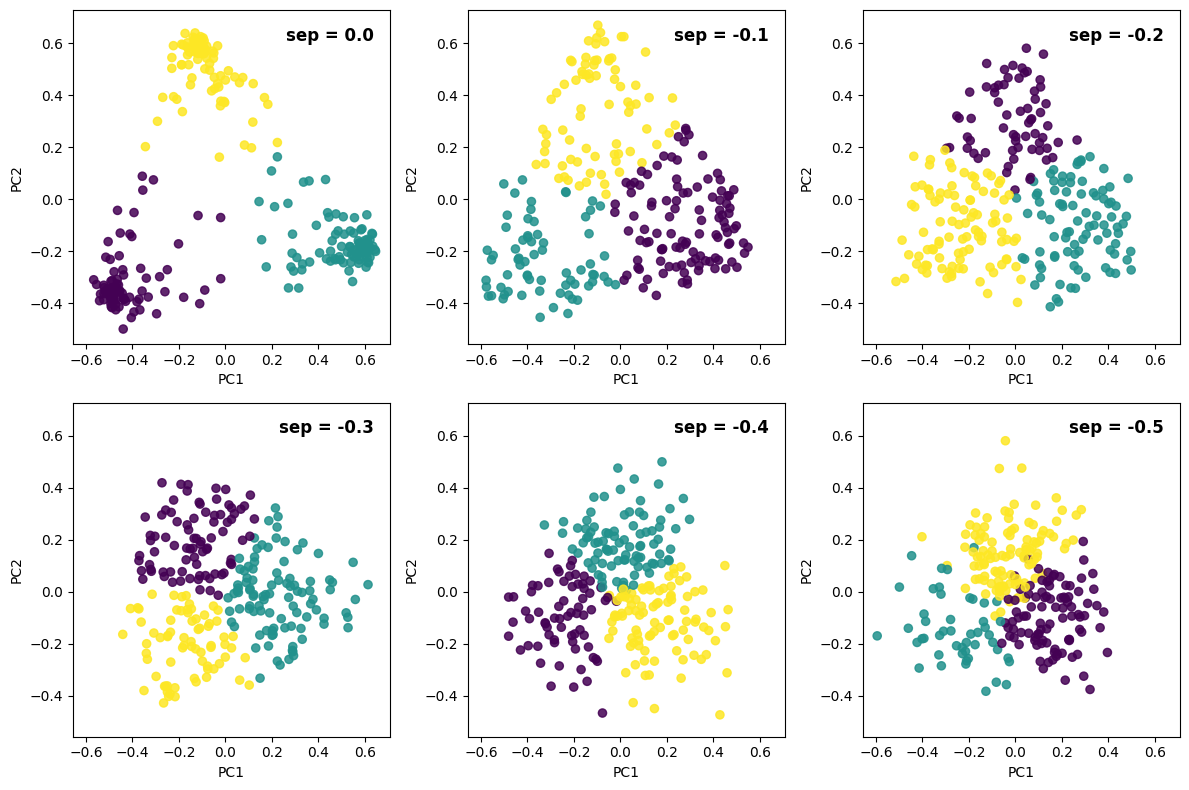

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

files = {
    "sep = 0.0": "Sep0_abundance.csv",
    "sep = -0.1": "Sep1_abundance.csv",
    "sep = -0.2": "Sep2_abundance.csv",
    "sep = -0.3": "Sep3_abundance.csv",
    "sep = -0.4": "Sep4_abundance.csv",
    "sep = -0.5": "Sep5_abundance.csv"
}

def hellinger_transform(X):
    row_sums = X.sum(axis=1)
    row_sums[row_sums == 0] = 1
    return np.sqrt(X / row_sums[:, None])

results = {}

# Önce tüm PCA koordinatlarını hesapla ve sakla
for title, file in files.items():
    df = pd.read_csv(file)
    X = df.select_dtypes(include=[np.number]).values

    X_hel = hellinger_transform(X)

    coords = PCA(n_components=2).fit_transform(X_hel)

    labels = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=20
    ).fit_predict(X_hel)

    results[title] = {
        "coords": coords,
        "labels": labels
    }

# Ortak eksen sınırları
all_coords = np.vstack([results[t]["coords"] for t in results])

x_min, x_max = all_coords[:, 0].min(), all_coords[:, 0].max()
y_min, y_max = all_coords[:, 1].min(), all_coords[:, 1].max()

# Biraz boşluk ekleyelim
x_pad = 0.05 * (x_max - x_min)
y_pad = 0.05 * (y_max - y_min)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, title in zip(axes, files.keys()):

    coords = results[title]["coords"]
    labels = results[title]["labels"]

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=labels,
        s=35,
        alpha=0.85,
        cmap="viridis"
    )

    ax.text(
        0.95, 0.95, title,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        ha="right",
        va="top"
    )

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.savefig("simulated_datasets_pca_common_scale.png", dpi=300, bbox_inches="tight")
plt.show()